In [31]:
%pip install transformers torch peft textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 1.6 MB/s eta 0:00:008.7 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, ElectraTokenizer, ElectraForSequenceClassification
import torch
from torch.optim import AdamW
from datasets import load_dataset
from transformers import DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType
import copy

MAX_LENGTH  = 64
BATCH_SIZE  = 16
EPOCHS      = 10
LR          = 5e-5
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, num_classes, max_length=512):
        # tokenize everything once at init time, not per-batch
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors="pt"
        )
        self.labels = torch.zeros(len(labels), num_classes)
        for i, label_list in enumerate(labels):
            if isinstance(label_list, int):
                label_list = [label_list]
            self.labels[i, label_list] = 1.0

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

def eval_model(model, loader):
    all_preds = []
    all_labels = []
    model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}  # <-- add this
            outputs = model(**batch)
            probs   = torch.sigmoid(outputs.logits)
            preds   = (probs > 0.5).int()
            all_preds.append(preds.cpu())
            all_labels.append(batch["labels"].int().cpu())
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    results_df = pd.DataFrame(
        np.hstack([all_labels, all_preds]),
        columns=label_cols + pred_cols
    )
    return results_df

In [3]:
def get_stats(df, name):
    y_true = df[label_cols].values
    y_pred = df[pred_cols].values
    
    # Per-class accuracy
    per_class = (y_true == y_pred).mean(axis=0)
    
    # Overall exact match
    exact = (y_true == y_pred).all(axis=1).mean()
    
    # Per-class F1, precision, recall
    report = classification_report(y_true, y_pred, output_dict=True)
    
    print(f"\n--- {name} ---")
    print(f"Exact match accuracy: {exact:.4f}")
    print(f"Macro F1:  {report['macro avg']['f1-score']:.4f}")
    print(f"Micro F1:  {report['weighted avg']['f1-score']:.4f}")
    return per_class, exact, report

In [4]:
def extract_labels(df, label_mappings):
    """
    Got this from Claude because I had only worked with Class n style labels and needed
    to shoehorn the actual class labels in once I found them
    Extracts y_true and y_pred from a df with one-hot Truth_/Predicted_ columns.
    For multi-label rows, each (true, predicted) pair is expanded into separate entries.
    """
    labels = list(label_mappings.values())
    truth_cols = {label: f'Truth_{label}' for label in labels}
    pred_cols  = {label: f'Predicted_{label}' for label in labels}

    y_true, y_pred = [], []

    for _, row in df.iterrows():
        true_labels = [label for label in labels if row.get(truth_cols[label], 0) == 1]
        pred_labels = [label for label in labels if row.get(pred_cols[label],  0) == 1]

        # Pair each true label with each predicted label (outer product)
        # Falls back to a dedicated "none" token if a side is empty
        for t in (true_labels or ['neutral']):
            for p in (pred_labels or ['neutral']):
                y_true.append(t)
                y_pred.append(p)

    return y_true, y_pred


def plot_confusion_heatmap(df, model_name, label_cols, pred_cols, label_mappings=None):
    y_true = df[label_cols].values
    y_pred = df[pred_cols].values
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    # --- Heatmap ---
    data = np.array([[m[1,1], m[0,1], m[1,0], m[0,0]] for m in mcm])
    row_labels = (
        [label_mappings[label_cols[i]] for i in range(len(label_cols))]
        if label_mappings else
        [f'Class {label_cols[i]}' for i in range(len(label_cols))]
    )
    sns.heatmap(
        data,
        annot=True, fmt='d', cmap='Blues',
        xticklabels=['TP', 'FP', 'FN', 'TN'],
        yticklabels=row_labels
    )
    plt.title(f'{model_name} — per-class confusion matrix')
    plt.tight_layout()
    plt.show()

    # --- Classification report ---
    target_names = row_labels
    report = classification_report(
        y_true, y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )
    report_df = pd.DataFrame(report).T
    print(f"\n{model_name} — classification report")
    print(report_df.to_string(float_format=lambda x: f"{x:.4f}"))
    
def plot_confusion_heatmap_grid(df, model_name, label_mappings):
    labels = list(label_mappings.values())
    y_true, y_pred = extract_labels(df, label_mappings)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_normalized = np.nan_to_num(cm_normalized)

    n = len(labels)
    fig, ax = plt.subplots(figsize=(14, 12))

    sns.heatmap(
        cm_normalized,
        ax=ax,
        cmap='Reds',
        xticklabels=labels,
        yticklabels=labels,
        vmin=0.0,
        vmax=1.0,
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'label': 'Proportion of Predictions', 'shrink': 0.6}
    )
    ax.set_title(f'{model_name} — Multilabel Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    ax.set_ylabel('True Label', fontsize=12, labelpad=10)
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

    plt.tight_layout()
    plt.savefig('confusion_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [5]:
def apply_lora(model, target_modules):
    config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=8,                  # rank — higher = more params, more capacity
        lora_alpha=16,        # scaling factor, typically 2x r
        lora_dropout=0.1,
        target_modules= target_modules
    )
    return get_peft_model(model, config)
    
def train(model, train_loader, val_loader, epochs=3, lr=2e-4, patience=3):
    optimizer = AdamW(model.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            del outputs, loss                          # free graph each step
        torch.cuda.empty_cache()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                val_loss += outputs.loss.item()
                del outputs                            # free activations each step
        torch.cuda.empty_cache()

        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch {epoch+1} — val loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(        # save checkpoint on CPU
                {k: v.cpu() for k, v in model.state_dict().items()}
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    return model

In [6]:
def save_model(model, tokenizer, save_path):
    import os
    os.makedirs(save_path, exist_ok=True)
    model.save_pretrained(save_path)       # PEFT-aware, handles base_model.model. prefix correctly
    tokenizer.save_pretrained(save_path)
    print(f"Model saved to {save_path}")

def load_model(save_path, base_model_name, num_labels):
    from peft import PeftModel
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    base_model = AutoModelForSequenceClassification.from_pretrained(
        base_model_name,
        num_labels=num_labels
    )
    model = PeftModel.from_pretrained(base_model, save_path)  # reattaches LoRA adapters
    tokenizer = AutoTokenizer.from_pretrained(save_path)
    return model, tokenizer

In [7]:
# Define Data & Splits

splits = {'train': 'simplified/train-00000-of-00001.parquet', 'validation': 'simplified/validation-00000-of-00001.parquet', 'test': 'simplified/test-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/" + splits["train"])
# df_train = df_train.iloc[:10,:]
df_val = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/" + splits["validation"])
# df_val = df_val.iloc[:10,:]
df_test = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/" + splits["test"])
# df_test = df_test.iloc[:10,:]
df_train.head()


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [8]:
all_labels = df_train["labels"].explode()
NUM_LABELS = int(all_labels.max()) + 1
label_mappings = {0: 'admiration',1: 'amusement',2: 'anger',3: 'annoyance',4: 'approval',5: 'caring',6: 'confusion',7: 'curiosity',
                  8: 'desire',9: 'disappointment',10: 'disapproval',11: 'disgust',12: 'embarrassment',13: 'excitement',14: 'fear',
                  15: 'gratitude',16: 'grief',17: 'joy',18: 'love',19: 'nervousness',20: 'optimism',21: 'pride',22: 'realization',
                  23: 'relief',24: 'remorse',25: 'sadness',26: 'surprise',27: 'neutral'}
pred_cols  = [f"Predicted_{label_mappings[i]}"  for i in range(NUM_LABELS)]
label_cols = [f"Truth_{label_mappings[i]}" for i in range(NUM_LABELS)]

In [9]:
# Make the data splits for each model

#----------------
# Electra
#----------------
electra_tokenizer = ElectraTokenizer.from_pretrained('google/electra-base-discriminator')

electra_train_dataset = TextDataset(df_train["text"].tolist(), df_train["labels"].tolist(), electra_tokenizer, NUM_LABELS)
electra_val_dataset   = TextDataset(df_val["text"].tolist(),   df_val["labels"].tolist(),   electra_tokenizer, NUM_LABELS)
electra_test_dataset   = TextDataset(df_test["text"].tolist(),   df_test["labels"].tolist(),   electra_tokenizer, NUM_LABELS)

electra_train_loader  = DataLoader(electra_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
electra_val_loader    = DataLoader(electra_val_dataset,   batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
electra_test_loader    = DataLoader(electra_test_dataset,   batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)

#----------------
# DistilBERT
#----------------
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

distilbert_train_dataset = TextDataset(df_train["text"].tolist(), df_train["labels"].tolist(), distilbert_tokenizer, NUM_LABELS)
distilbert_val_dataset   = TextDataset(df_val["text"].tolist(),   df_val["labels"].tolist(),   distilbert_tokenizer, NUM_LABELS)
distilbert_test_dataset   = TextDataset(df_test["text"].tolist(),   df_test["labels"].tolist(),   distilbert_tokenizer, NUM_LABELS)

distilbert_train_loader  = DataLoader(distilbert_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
distilbert_val_loader    = DataLoader(distilbert_val_dataset,   batch_size=BATCH_SIZE)
distilbert_test_loader    = DataLoader(distilbert_test_dataset,   batch_size=BATCH_SIZE)

In [10]:
# Electra Base Model

electra_base_model = ElectraForSequenceClassification.from_pretrained(
    'google/electra-base-discriminator',
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# DistilBERT Base Model

distilbert_base_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
electra_results_df = eval_model(electra_base_model, electra_val_loader)
distilbert_results_df = eval_model(distilbert_base_model, distilbert_val_loader)

In [13]:
db_per_class, db_exact, db_report = get_stats(distilbert_results_df, "DistilBERT")
el_per_class, el_exact, el_report = get_stats(electra_results_df,    "ELECTRA")

db_preds = distilbert_results_df[pred_cols].values
el_preds = electra_results_df[pred_cols].values
disagreement_rate = (db_preds != el_preds).mean(axis=0)

print("\n--- Per-class disagreement between models ---")
for i, rate in enumerate(disagreement_rate):
    if i < 28: # all right this is weird. I cannot figure out where the 28th label is coming from and no longer care
        print(f"  {label_mappings[i]}: {rate:.2%} of samples differ")


--- DistilBERT ---
Exact match accuracy: 0.0000
Macro F1:  0.0517
Micro F1:  0.1645

--- ELECTRA ---
Exact match accuracy: 0.0000
Macro F1:  0.0607
Micro F1:  0.1361

--- Per-class disagreement between models ---
  admiration: 91.36% of samples differ
  amusement: 14.34% of samples differ
  anger: 49.06% of samples differ
  annoyance: 42.30% of samples differ
  approval: 72.02% of samples differ
  caring: 45.25% of samples differ
  confusion: 62.90% of samples differ
  curiosity: 86.40% of samples differ
  desire: 81.24% of samples differ
  disappointment: 55.73% of samples differ
  disapproval: 23.07% of samples differ
  disgust: 68.85% of samples differ
  embarrassment: 60.80% of samples differ
  excitement: 27.24% of samples differ
  fear: 23.88% of samples differ
  gratitude: 94.54% of samples differ
  grief: 17.25% of samples differ
  joy: 94.25% of samples differ
  love: 48.36% of samples differ
  nervousness: 23.35% of samples differ
  optimism: 70.81% of samples differ
  pride

/home/jj/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


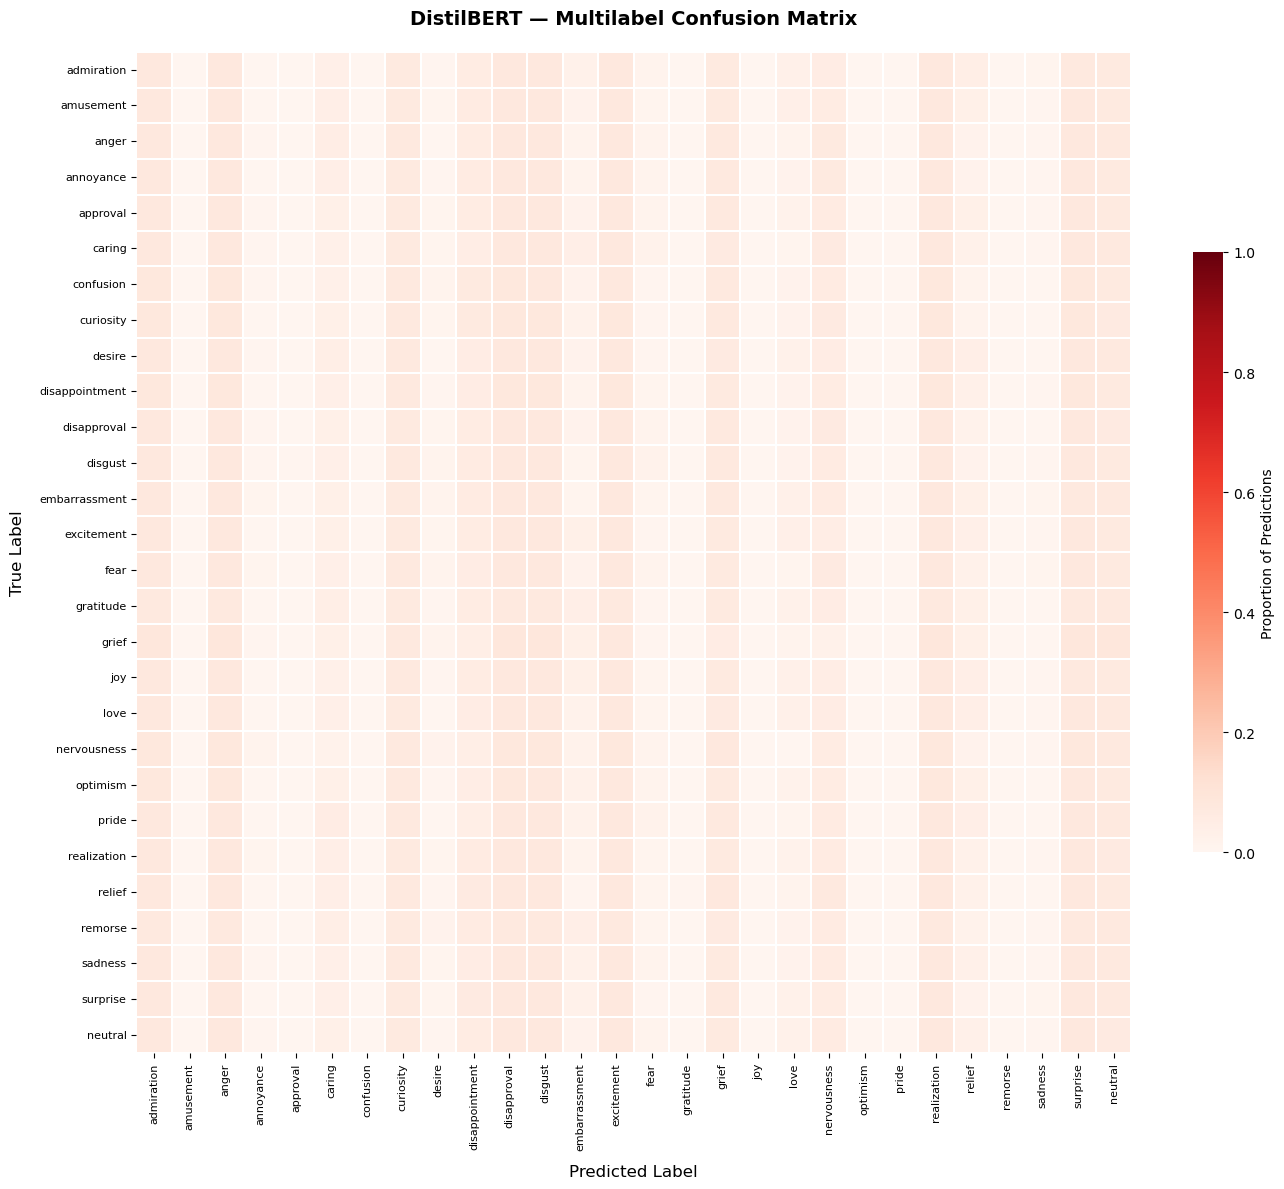

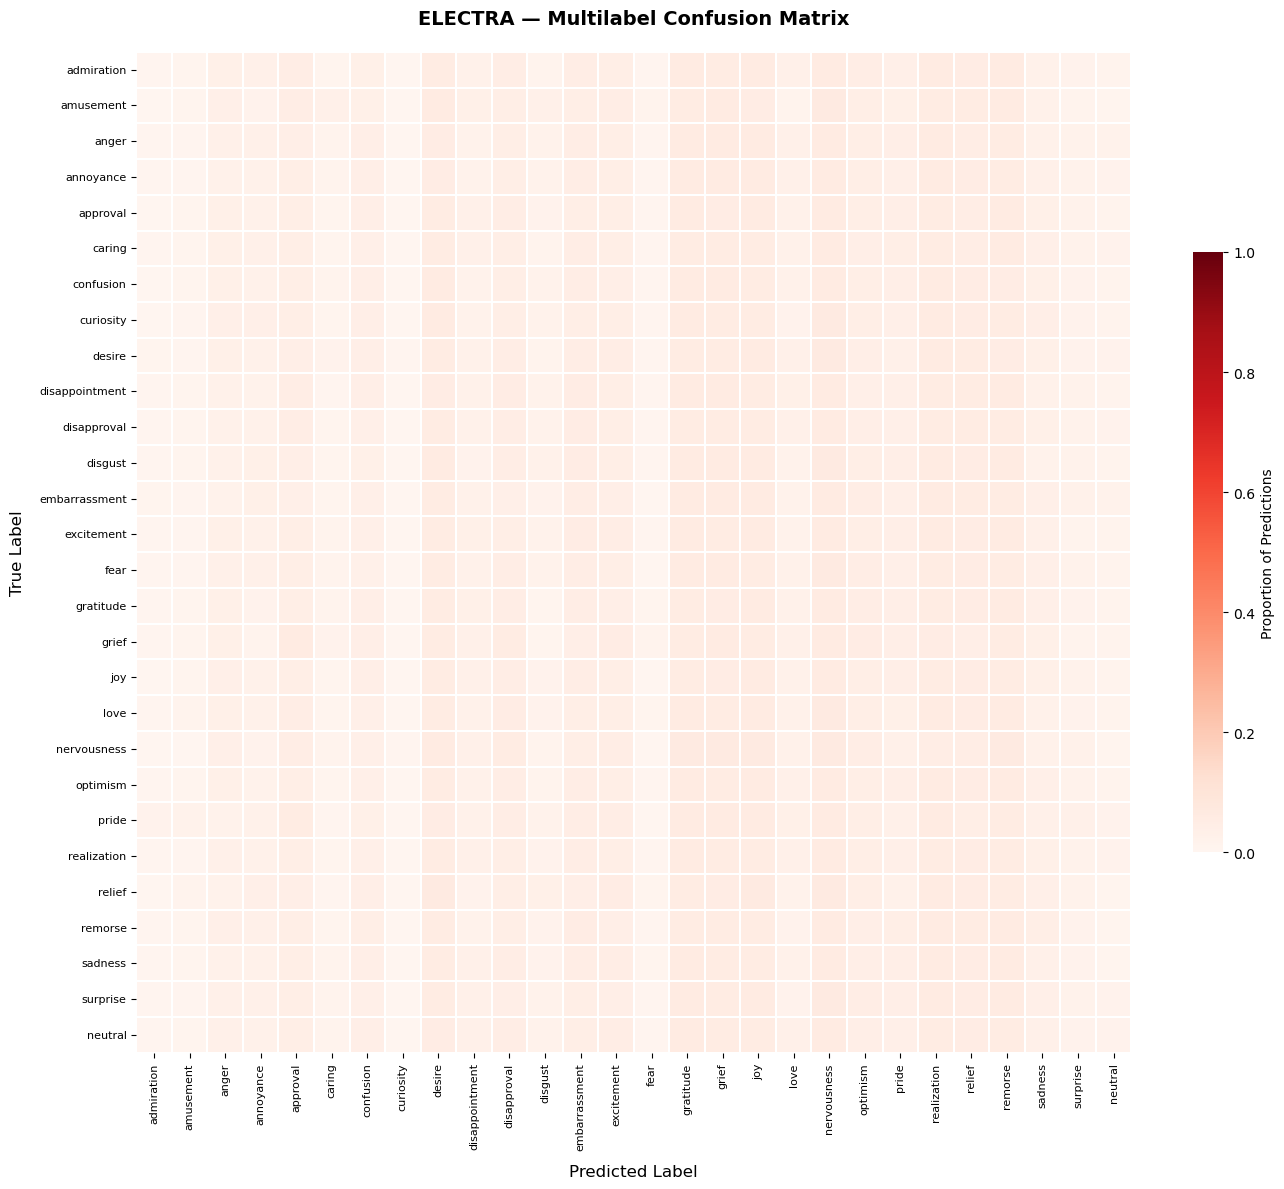

In [14]:
plot_confusion_heatmap_grid(distilbert_results_df, 'DistilBERT', label_mappings)
plot_confusion_heatmap_grid(electra_results_df, 'ELECTRA', label_mappings)

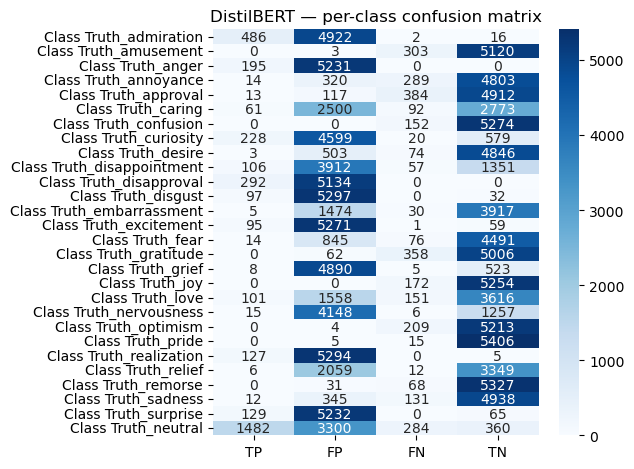


DistilBERT — classification report
                            precision  recall  f1-score   support
Class Truth_admiration         0.0899  0.9959    0.1649  488.0000
Class Truth_amusement          0.0000  0.0000    0.0000  303.0000
Class Truth_anger              0.0359  1.0000    0.0694  195.0000
Class Truth_annoyance          0.0419  0.0462    0.0440  303.0000
Class Truth_approval           0.1000  0.0327    0.0493  397.0000
Class Truth_caring             0.0238  0.3987    0.0450  153.0000
Class Truth_confusion          0.0000  0.0000    0.0000  152.0000
Class Truth_curiosity          0.0472  0.9194    0.0899  248.0000
Class Truth_desire             0.0059  0.0390    0.0103   77.0000
Class Truth_disappointment     0.0264  0.6503    0.0507  163.0000
Class Truth_disapproval        0.0538  1.0000    0.1021  292.0000
Class Truth_disgust            0.0180  1.0000    0.0353   97.0000
Class Truth_embarrassment      0.0034  0.1429    0.0066   35.0000
Class Truth_excitement         0.0177  0

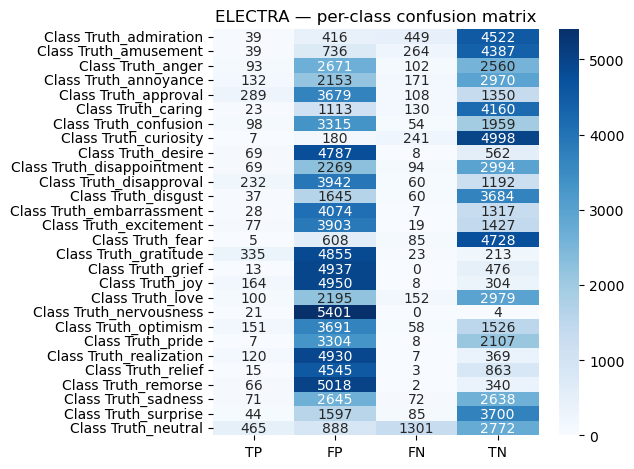


ELECTRA — classification report
                            precision  recall  f1-score   support
Class Truth_admiration         0.0857  0.0799    0.0827  488.0000
Class Truth_amusement          0.0503  0.1287    0.0724  303.0000
Class Truth_anger              0.0336  0.4769    0.0629  195.0000
Class Truth_annoyance          0.0578  0.4356    0.1020  303.0000
Class Truth_approval           0.0728  0.7280    0.1324  397.0000
Class Truth_caring             0.0202  0.1503    0.0357  153.0000
Class Truth_confusion          0.0287  0.6447    0.0550  152.0000
Class Truth_curiosity          0.0374  0.0282    0.0322  248.0000
Class Truth_desire             0.0142  0.8961    0.0280   77.0000
Class Truth_disappointment     0.0295  0.4233    0.0552  163.0000
Class Truth_disapproval        0.0556  0.7945    0.1039  292.0000
Class Truth_disgust            0.0220  0.3814    0.0416   97.0000
Class Truth_embarrassment      0.0068  0.8000    0.0135   35.0000
Class Truth_excitement         0.0193  0.80

In [15]:
plot_confusion_heatmap(distilbert_results_df, 'DistilBERT', label_cols, pred_cols)
plot_confusion_heatmap(electra_results_df,    'ELECTRA',    label_cols, pred_cols)

In [22]:
# -------------------------
# Finetuning Starts Here
#--------------------------
# for name, module in electra_base_model.named_modules():
#     print(name)
# for name, module in distilbert_base_model.named_modules():
#     print(name)

distilbert_lora_model = apply_lora(distilbert_base_model, ["q_lin", "v_lin"]) # Totally just asked Claude what to put here. No clue
electra_lora_model = apply_lora(electra_base_model, ["query", "value"]) # Here too

In [23]:
print('Training DistilBERT')
distilbert_fine_model = train(distilbert_lora_model, distilbert_train_loader, distilbert_val_loader, epochs=EPOCHS, lr=LR)
print('Training Electra')
electra_fine_model = train(electra_lora_model,electra_train_loader, electra_val_loader, epochs=EPOCHS, lr=LR)

Training DistilBERT
Epoch 1 — val loss: 0.0928
Epoch 2 — val loss: 0.0873
Epoch 3 — val loss: 0.0856
Epoch 4 — val loss: 0.0843
Epoch 5 — val loss: 0.0839
Epoch 6 — val loss: 0.0836
Epoch 7 — val loss: 0.0827
Epoch 8 — val loss: 0.0822
Epoch 9 — val loss: 0.0821
Epoch 10 — val loss: 0.0820
Training Electra


OutOfMemoryError: CUDA out of memory. Tried to allocate 192.00 MiB. GPU 0 has a total capacity of 7.64 GiB of which 176.62 MiB is free. Including non-PyTorch memory, this process has 7.19 GiB memory in use. Of the allocated memory 6.92 GiB is allocated by PyTorch, and 75.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
distilbert_fine_results_df = eval_model(distilbert_fine_model, distilbert_test_loader)
electra_fine_results_df = eval_model(electra_fine_model, electra_test_loader)

In [ ]:
db_per_class, db_exact, db_report = get_stats(distilbert_fine_results_df, "DistilBERT")
el_per_class, el_exact, el_report = get_stats(electra_fine_results_df,    "ELECTRA")

db_preds = distilbert_fine_results_df[pred_cols].values
el_preds = electra_fine_results_df[pred_cols].values
disagreement_rate = (db_preds != el_preds).mean(axis=0)

print("\n--- Per-class disagreement between models ---")
for i, rate in enumerate(disagreement_rate):
    print(f"  {label_mappings[i]} : {rate:.2%} of samples differ")

plot_confusion_heatmap(distilbert_fine_results_df, 'DistilBERT', label_cols, pred_cols)
plot_confusion_heatmap(electra_fine_results_df,    'ELECTRA',    label_cols, pred_cols)

In [ ]:
df_train.shape

In [ ]:
df_val.shape

### df_test.shape

In [21]:
distilbert_fine_results_df = eval_model(distilbert_fine_model, distilbert_test_loader)

OutOfMemoryError: CUDA out of memory. Tried to allocate 24.00 MiB. GPU 0 has a total capacity of 7.64 GiB of which 32.12 MiB is free. Including non-PyTorch memory, this process has 7.39 GiB memory in use. Of the allocated memory 7.14 GiB is allocated by PyTorch, and 61.68 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [24]:
import gc
# Print a snapshot of what's currently living on the GPU
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            print(type(obj), obj.size(), obj.device)
    except:
        pass

<class 'torch.nn.parameter.Parameter'> torch.Size([30522, 768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([512, 768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.Parameter'> torch.Size([768]) cuda:0
<class 'torch.nn.parameter.P

/home/jj/anaconda3/lib/python3.12/site-packages/torch/__init__.py:1164: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


In [23]:
torch.cuda.empty_cache()

In [26]:
import gc
del distilbert_fine_model3

gc.collect()
torch.cuda.empty_cache()

In [26]:
distilbert_fine_model, distilbert_tokenizer = load_model( "./DistilBERT_5e5" )

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RuntimeError: Error(s) in loading state_dict for DistilBertForSequenceClassification:
	size mismatch for classifier.modules_to_save.default.weight: copying a param with shape torch.Size([28, 768]) from checkpoint, the shape in current model is torch.Size([2, 768]).
	size mismatch for classifier.modules_to_save.default.bias: copying a param with shape torch.Size([28]) from checkpoint, the shape in current model is torch.Size([2]).

In [24]:
def save_model(model, tokenizer, save_path):
    # Save HuggingFace parts the normal way
    model_to_save = model.module if hasattr(model, 'module') else model
    model_to_save.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    # Also save full state dict as a fallback
    torch.save(model_to_save.state_dict(), f"{save_path}/full_state_dict.pt")
    print(f"Model saved to {save_path}")

save_model(distilbert_fine_model,  distilbert_tokenizer, "./DistilBERT_5e5-2")

Model saved to ./DistilBERT_5e5-2


In [25]:
def load_model(save_path, model_class, tokenizer_class, num_labels):
    model = model_class.from_pretrained(save_path, num_labels=num_labels)
    state_dict = torch.load(f"{save_path}/full_state_dict.pt", map_location='cpu')
    model.load_state_dict(state_dict)
    tokenizer = tokenizer_class.from_pretrained(save_path)
    return model, tokenizer

# --- Usage ---
from transformers import AutoModelForSequenceClassification, AutoTokenizer

distilbert_fine_model2,  distilbert_tokenizer2 = load_model(
    save_path="./DistilBERT_5e5-2",
    model_class=AutoModelForSequenceClassification,
    tokenizer_class=AutoTokenizer,
    num_labels=28
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RuntimeError: Error(s) in loading state_dict for DistilBertForSequenceClassification:
	Missing key(s) in state_dict: "distilbert.embeddings.word_embeddings.weight", "distilbert.embeddings.position_embeddings.weight", "distilbert.embeddings.LayerNorm.weight", "distilbert.embeddings.LayerNorm.bias", "distilbert.transformer.layer.0.attention.q_lin.base_layer.weight", "distilbert.transformer.layer.0.attention.q_lin.base_layer.bias", "distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight", "distilbert.transformer.layer.0.attention.q_lin.lora_B.default.weight", "distilbert.transformer.layer.0.attention.k_lin.weight", "distilbert.transformer.layer.0.attention.k_lin.bias", "distilbert.transformer.layer.0.attention.v_lin.base_layer.weight", "distilbert.transformer.layer.0.attention.v_lin.base_layer.bias", "distilbert.transformer.layer.0.attention.v_lin.lora_A.default.weight", "distilbert.transformer.layer.0.attention.v_lin.lora_B.default.weight", "distilbert.transformer.layer.0.a

In [3]:


# --- Usage ---

save_model(distilbert_fine_model,  distilbert_tokenizer, "./DistilBERT_5e5-3")

distilbert_fine_model3,  distilbert_tokenizer3 = load_model(
    save_path="./DistilBERT_5e5-2",
    base_model_name="distilbert-base-uncased",
    num_labels=28
)



NameError: name 'distilbert_fine_model' is not defined

In [16]:
distilbert_fine_model3,  distilbert_tokenizer3 = load_model(
    save_path="./DistilBERT_5e5-3",
    base_model_name="distilbert-base-uncased",
    num_labels=28
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
distilbert_fine_results_df = eval_model(distilbert_fine_model3, distilbert_test_loader)

NameError: name 'distilbert_test_loader' is not defined

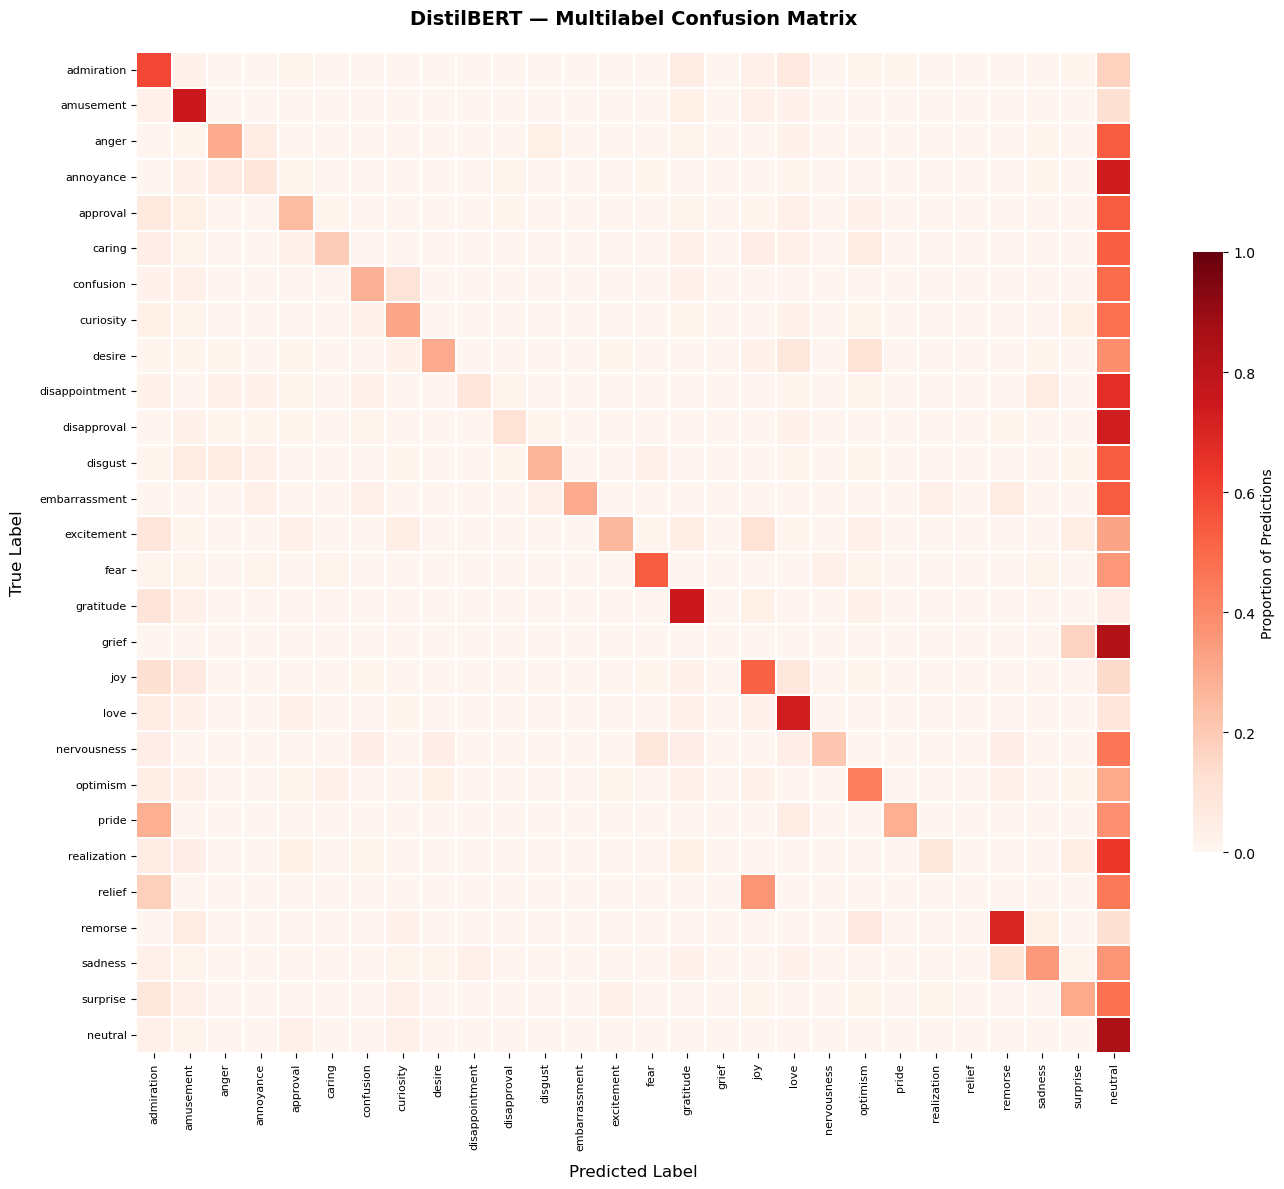

In [23]:
plot_confusion_heatmap_grid(distilbert_fine_results_df, 'DistilBERT', label_mappings)

In [9]:
electra_tokenizer = ElectraTokenizer.from_pretrained('google/electra-base-discriminator')

electra_train_dataset = TextDataset(df_train["text"].tolist(), df_train["labels"].tolist(), electra_tokenizer, NUM_LABELS)
electra_val_dataset   = TextDataset(df_val["text"].tolist(),   df_val["labels"].tolist(),   electra_tokenizer, NUM_LABELS)
electra_test_dataset   = TextDataset(df_test["text"].tolist(),   df_test["labels"].tolist(),   electra_tokenizer, NUM_LABELS)

electra_train_loader  = DataLoader(electra_train_dataset, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
electra_val_loader    = DataLoader(electra_val_dataset,   batch_size=8, num_workers=4, pin_memory=True)
electra_test_loader    = DataLoader(electra_test_dataset,   batch_size=8, num_workers=4, pin_memory=True)

# Electra Base Model

electra_base_model = ElectraForSequenceClassification.from_pretrained(
    'google/electra-base-discriminator',
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

electra_lora_model = apply_lora(electra_base_model, ["query", "value"]) # Here too
print('Training Electra')
electra_fine_model = train(electra_lora_model,electra_train_loader, electra_val_loader, epochs=EPOCHS, lr=LR)

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Electra
Epoch 1 — val loss: 0.0994
Epoch 2 — val loss: 0.0941
Epoch 3 — val loss: 0.0897
Epoch 4 — val loss: 0.0903
Epoch 5 — val loss: 0.0922
Epoch 6 — val loss: 0.0877
Epoch 7 — val loss: 0.0888
Epoch 8 — val loss: 0.0842
Epoch 9 — val loss: 0.0856
Epoch 10 — val loss: 0.0852


In [12]:
save_model(electra_fine_model,  electra_tokenizer, "./Electra_5e5-3")

electra_fine_model3,  electra_tokenizer3 = load_model(
    save_path="./Electra_5e5-3",
    base_model_name="google/electra-base-discriminator",
    num_labels=28
)



Model saved to ./Electra_5e5-3


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
electra_fine_results_df = eval_model(electra_fine_model3, electra_test_loader)

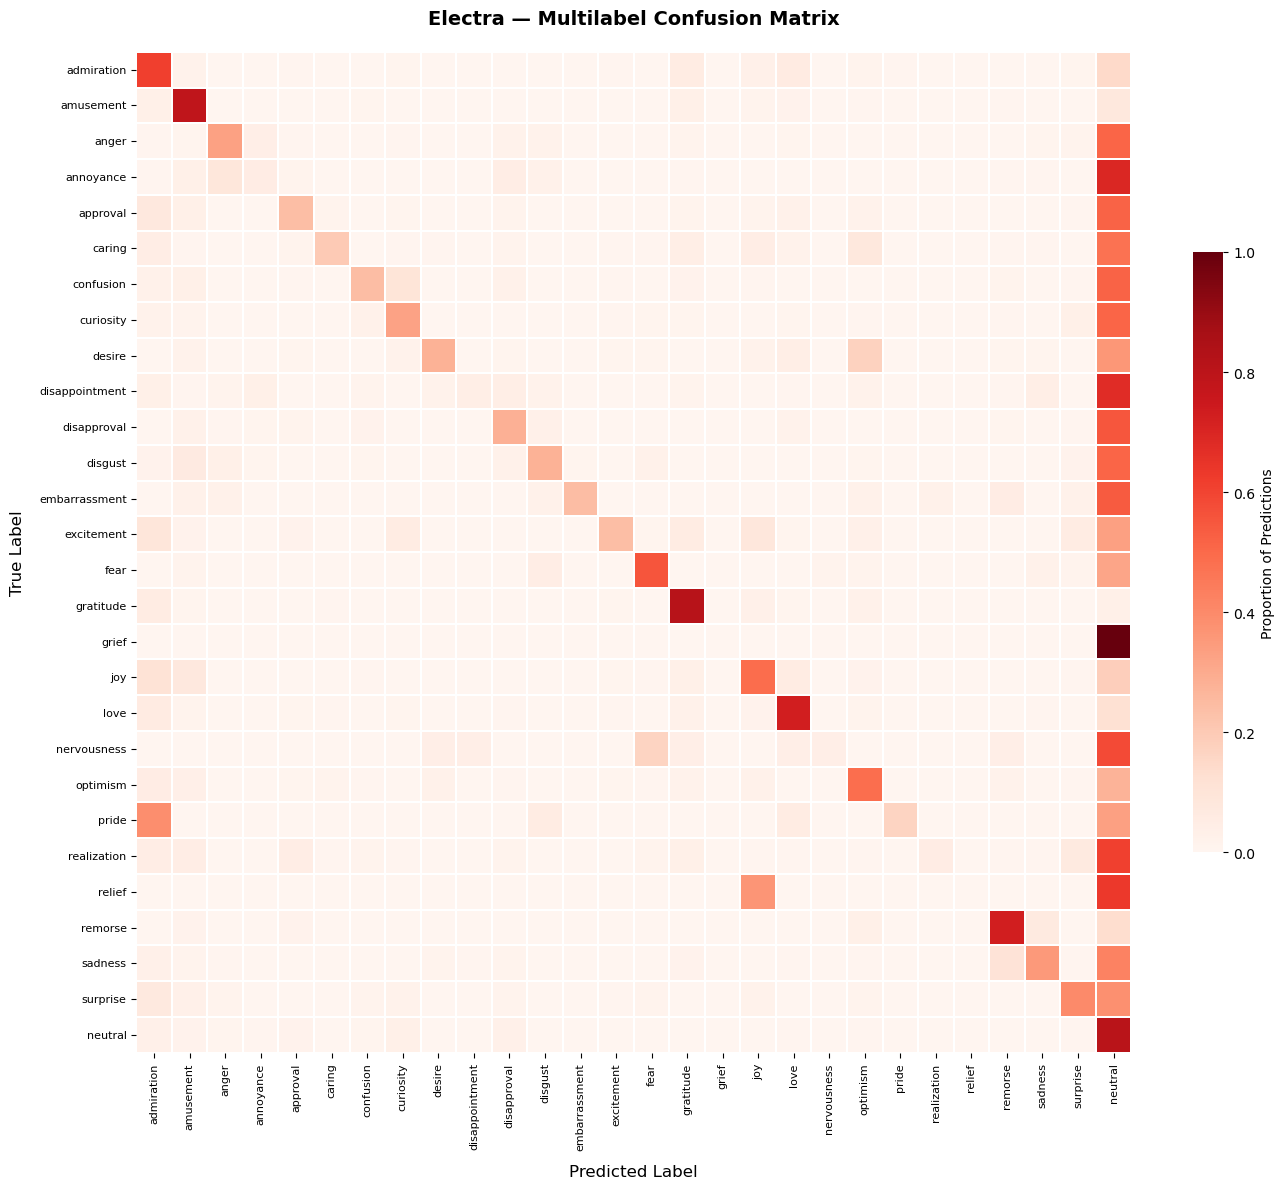

In [14]:
plot_confusion_heatmap_grid(electra_fine_results_df, 'Electra', label_mappings)


--- DistilBERT Finetuned ---
Exact match accuracy: 0.4472
Macro F1:  0.4378
Micro F1:  0.5369

--- ELECTRA Finetuned ---
Exact match accuracy: 0.4384
Macro F1:  0.4185
Micro F1:  0.5314

--- Per-class disagreement between models ---
  admiration : 3.17% of samples differ
  amusement : 1.00% of samples differ
  anger : 1.25% of samples differ
  annoyance : 0.88% of samples differ
  approval : 1.71% of samples differ
  caring : 0.76% of samples differ
  confusion : 0.96% of samples differ
  curiosity : 2.03% of samples differ
  desire : 0.28% of samples differ
  disappointment : 0.29% of samples differ
  disapproval : 2.28% of samples differ
  disgust : 0.79% of samples differ
  embarrassment : 0.20% of samples differ
  excitement : 0.44% of samples differ
  fear : 0.50% of samples differ
  gratitude : 0.41% of samples differ
  grief : 0.00% of samples differ
  joy : 0.74% of samples differ
  love : 0.79% of samples differ
  nervousness : 0.18% of samples differ
  optimism : 0.85% of sa

/home/jj/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/jj/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/jj/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/jj/anaconda3/lib/py

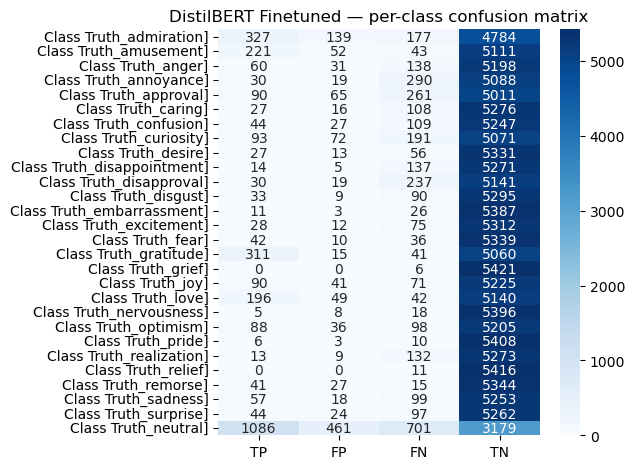

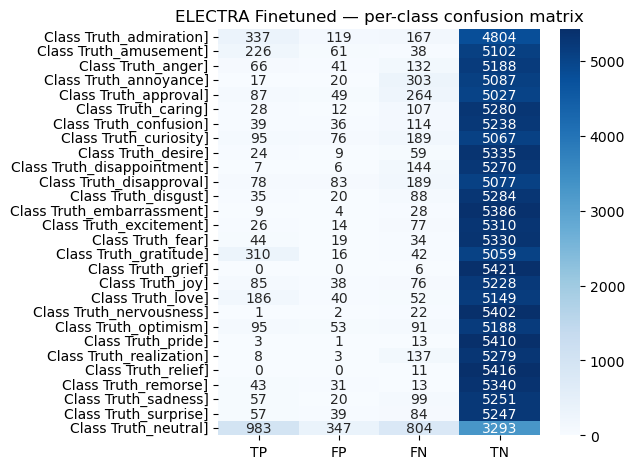

In [23]:
db_per_class, db_exact, db_report = get_stats(distilbert_fine_results_df, "DistilBERT Finetuned")
el_per_class, el_exact, el_report = get_stats(electra_fine_results_df,    "ELECTRA Finetuned")

db_preds = distilbert_fine_results_df[pred_cols].values
el_preds = electra_fine_results_df[pred_cols].values
disagreement_rate = (db_preds != el_preds).mean(axis=0)

print("\n--- Per-class disagreement between models ---")
for i, rate in enumerate(disagreement_rate):
    print(f"  {label_mappings[i]} : {rate:.2%} of samples differ")

plot_confusion_heatmap(distilbert_fine_results_df, 'DistilBERT Finetuned', label_cols, pred_cols)
plot_confusion_heatmap(electra_fine_results_df,    'ELECTRA Finetuned',    label_cols, pred_cols)

In [19]:
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

distilbert_train_dataset = TextDataset(df_train["text"].tolist(), df_train["labels"].tolist(), distilbert_tokenizer, NUM_LABELS)
distilbert_val_dataset   = TextDataset(df_val["text"].tolist(),   df_val["labels"].tolist(),   distilbert_tokenizer, NUM_LABELS)
distilbert_test_dataset   = TextDataset(df_test["text"].tolist(),   df_test["labels"].tolist(),   distilbert_tokenizer, NUM_LABELS)

distilbert_train_loader  = DataLoader(distilbert_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
distilbert_val_loader    = DataLoader(distilbert_val_dataset,   batch_size=BATCH_SIZE)
distilbert_test_loader    = DataLoader(distilbert_test_dataset,   batch_size=BATCH_SIZE)

In [20]:
distilbert_fine_results_df = eval_model(distilbert_fine_model3, distilbert_test_loader)

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


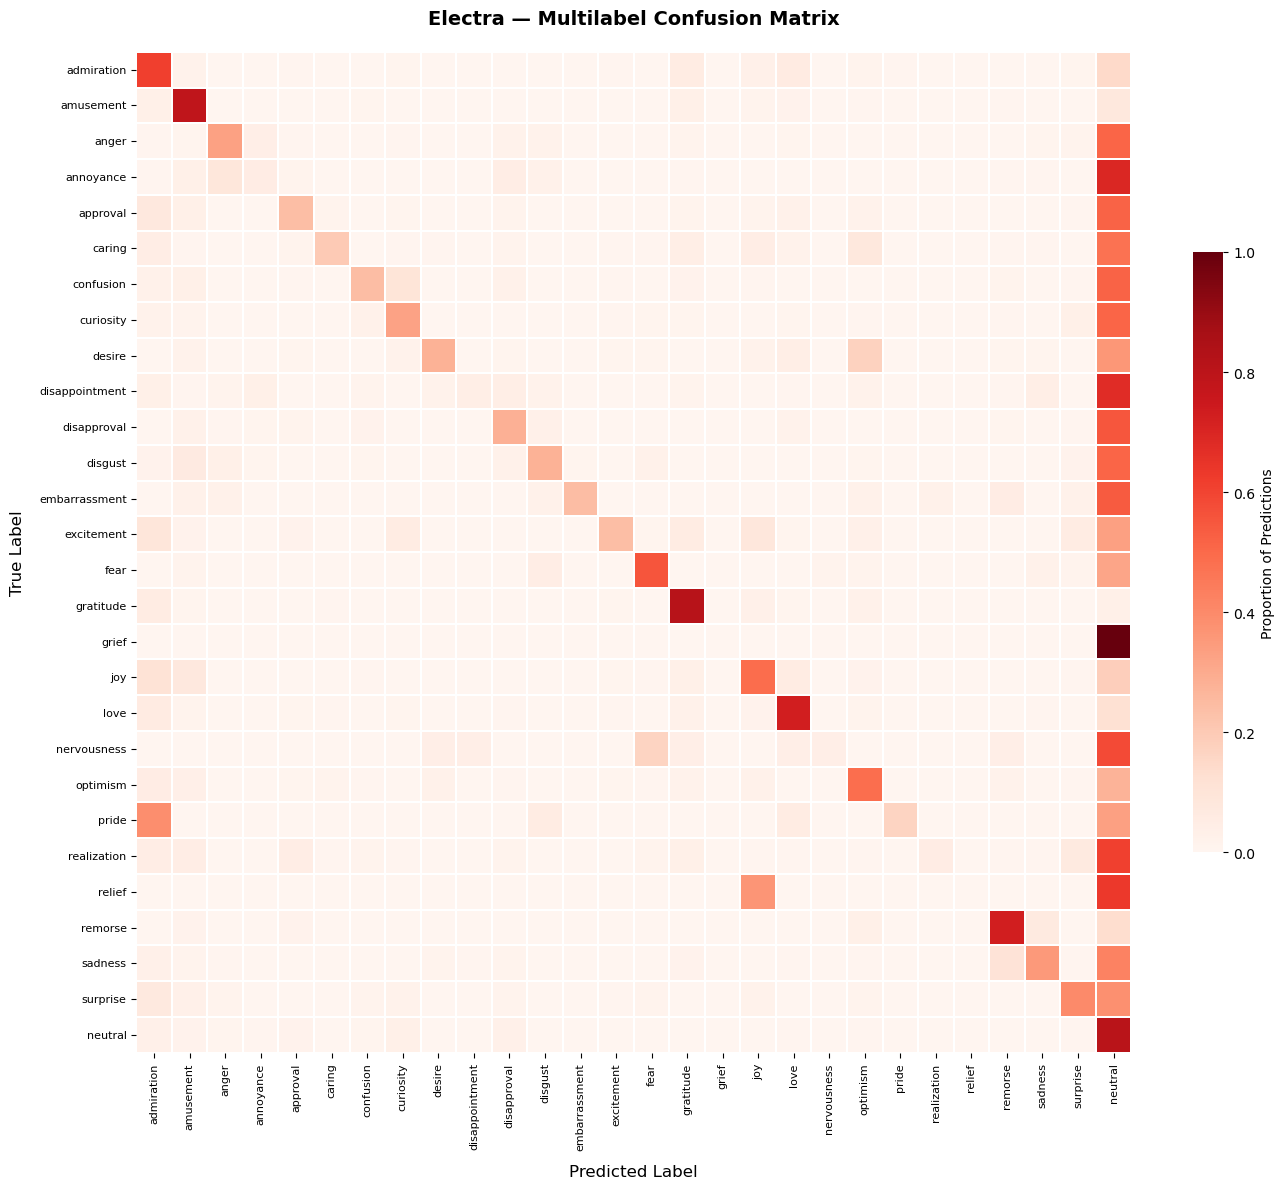

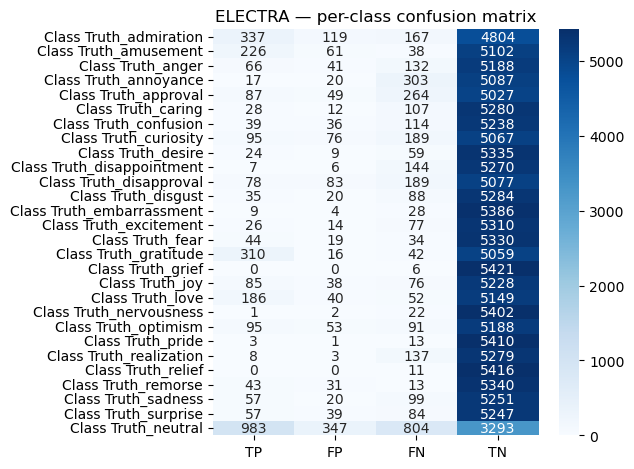


ELECTRA — classification report
                            precision  recall  f1-score   support
Class Truth_admiration         0.7390  0.6687    0.7021  504.0000
Class Truth_amusement          0.7875  0.8561    0.8203  264.0000
Class Truth_anger              0.6168  0.3333    0.4328  198.0000
Class Truth_annoyance          0.4595  0.0531    0.0952  320.0000
Class Truth_approval           0.6397  0.2479    0.3573  351.0000
Class Truth_caring             0.7000  0.2074    0.3200  135.0000
Class Truth_confusion          0.5200  0.2549    0.3421  153.0000
Class Truth_curiosity          0.5556  0.3345    0.4176  284.0000
Class Truth_desire             0.7273  0.2892    0.4138   83.0000
Class Truth_disappointment     0.5385  0.0464    0.0854  151.0000
Class Truth_disapproval        0.4845  0.2921    0.3645  267.0000
Class Truth_disgust            0.6364  0.2846    0.3933  123.0000
Class Truth_embarrassment      0.6923  0.2432    0.3600   37.0000
Class Truth_excitement         0.6500  0.25

TypeError: 'PeftModelForSequenceClassification' object is not subscriptable

In [17]:
electra_fine_model3,  electra_tokenizer3 = load_model(
    save_path="./Electra_5e5-3",
    base_model_name="google/electra-base-discriminator",
    num_labels=28
)
distilbert_fine_model3,  distilbert_tokenizer3 = load_model(
    save_path="./DistilBERT_5e5-3",
    base_model_name="distilbert-base-uncased",
    num_labels=28
)
electra_fine_results_df = eval_model(electra_fine_model3, electra_test_loader)
plot_confusion_heatmap_grid(electra_fine_results_df, 'Electra', label_mappings)
plot_confusion_heatmap(electra_fine_results_df,    'ELECTRA',    label_cols, pred_cols)

distilbert_fine_results_df = eval_model(distilbert_fine_model3, distilbert_test_loader)
plot_confusion_heatmap(distilbert_fine_results_df, 'DistilBERT', label_cols, pred_cols)
plot_confusion_heatmap(distilbert_fine_results_df,    'DistilBERT',    label_cols, pred_cols)



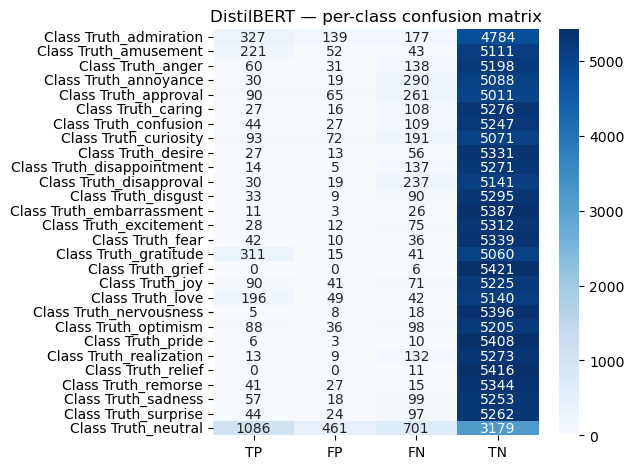


DistilBERT — classification report
                            precision  recall  f1-score   support
Class Truth_admiration         0.7017  0.6488    0.6742  504.0000
Class Truth_amusement          0.8095  0.8371    0.8231  264.0000
Class Truth_anger              0.6593  0.3030    0.4152  198.0000
Class Truth_annoyance          0.6122  0.0938    0.1626  320.0000
Class Truth_approval           0.5806  0.2564    0.3557  351.0000
Class Truth_caring             0.6279  0.2000    0.3034  135.0000
Class Truth_confusion          0.6197  0.2876    0.3929  153.0000
Class Truth_curiosity          0.5636  0.3275    0.4143  284.0000
Class Truth_desire             0.6750  0.3253    0.4390   83.0000
Class Truth_disappointment     0.7368  0.0927    0.1647  151.0000
Class Truth_disapproval        0.6122  0.1124    0.1899  267.0000
Class Truth_disgust            0.7857  0.2683    0.4000  123.0000
Class Truth_embarrassment      0.7857  0.2973    0.4314   37.0000
Class Truth_excitement         0.7000  0

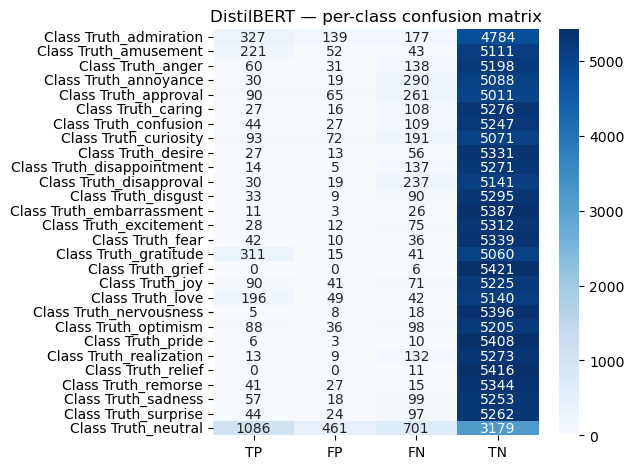


DistilBERT — classification report
                            precision  recall  f1-score   support
Class Truth_admiration         0.7017  0.6488    0.6742  504.0000
Class Truth_amusement          0.8095  0.8371    0.8231  264.0000
Class Truth_anger              0.6593  0.3030    0.4152  198.0000
Class Truth_annoyance          0.6122  0.0938    0.1626  320.0000
Class Truth_approval           0.5806  0.2564    0.3557  351.0000
Class Truth_caring             0.6279  0.2000    0.3034  135.0000
Class Truth_confusion          0.6197  0.2876    0.3929  153.0000
Class Truth_curiosity          0.5636  0.3275    0.4143  284.0000
Class Truth_desire             0.6750  0.3253    0.4390   83.0000
Class Truth_disappointment     0.7368  0.0927    0.1647  151.0000
Class Truth_disapproval        0.6122  0.1124    0.1899  267.0000
Class Truth_disgust            0.7857  0.2683    0.4000  123.0000
Class Truth_embarrassment      0.7857  0.2973    0.4314   37.0000
Class Truth_excitement         0.7000  0

In [18]:
plot_confusion_heatmap(distilbert_fine_results_df, 'DistilBERT', label_cols, pred_cols)
plot_confusion_heatmap(distilbert_fine_results_df,    'DistilBERT',    label_cols, pred_cols)